<a href="https://colab.research.google.com/github/zilioalberto/Ciencia_De_Dados_Analise_Exploratoria_Parte_02/blob/main/An%C3%A1lise_Explorat%C3%B3ria_para_Modelagem_Parte_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análise Exploratória para Modelagem
## Parte 02 - Análise do Projeto de Regressão (Preços de Carros)
## Alunos:
## Alberto Zilio
## Roni Pereira



In [12]:
# Bibliotecas

import os, glob
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


In [3]:
# Importação do algoritimo do github
# Data Set escolhido:  https://archive.ics.uci.edu/dataset/10/automobile

# ===== Config =====
OWNER  = "zilioalberto"
REPO   = "Ciencia_De_Dados_Analise_Exploratoria_Parte_02"
FOLDER = "automobile"     # pasta que contém os 4 arquivos
BRANCH = "main"


api_url = f"https://api.github.com/repos/{OWNER}/{REPO}/contents/{quote(FOLDER)}?ref={BRANCH}"


headers = {}

r = requests.get(api_url, headers=headers, timeout=30)
r.raise_for_status()
items = r.json()

files = [it for it in items if it.get("type") == "file"]
os.makedirs(f"/content/data/{FOLDER}", exist_ok=True)

print(f"Arquivos encontrados em {FOLDER}:")
for it in files:
    print(" -", it["name"])

for it in files:
    url = it["download_url"]
    name = it["name"]
    dest = f"/content/data/{FOLDER}/{name}"
    resp = requests.get(url, headers=headers, timeout=60)
    resp.raise_for_status()
    with open(dest, "wb") as f:
        f.write(resp.content)
    print(f"✔ Baixado: {dest}")

print("\nPronto. Pasta local:", f"/content/data/{FOLDER}")




Arquivos encontrados em automobile:
 - Index
 - imports-85.data
 - imports-85.names
 - misc
✔ Baixado: /content/data/automobile/Index
✔ Baixado: /content/data/automobile/imports-85.data
✔ Baixado: /content/data/automobile/imports-85.names
✔ Baixado: /content/data/automobile/misc

Pronto. Pasta local: /content/data/automobile


In [6]:
# Passo 01 - Carregamento e Diagnóstico:

BASE_DIR = "/content/data/automobile"

# 1) Localizar o arquivo (aceita .data, .csv, etc.)
patterns = ["*imports*85*.data", "*automobile*.csv", "*Automobile*.csv", "*.data", "*.csv", "*.txt"]
candidates = []
for pat in patterns:
    candidates += glob.glob(os.path.join(BASE_DIR, pat))

if not candidates:
    raise FileNotFoundError(
        f"Nenhum dataset encontrado em {BASE_DIR}. "
        f"Verifique o caminho e se o arquivo foi enviado (ex.: 'imports-85.data')."
    )

data_path = sorted(candidates, key=len)[0]  # pega o mais provável
print(f"Usando arquivo: {os.path.basename(data_path)}")

# 2) Nomes de colunas oficiais do Automobile (UCI) — 26 colunas
COLS = [
    'symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors',
    'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
    'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system',
    'bore','stroke','compression-ratio','horsepower','peak-rpm',
    'city-mpg','highway-mpg','price'
]

# 3) Carregar tratando:
#    - ausência de cabeçalho (header=None + names=COLS)
#    - valores ausentes representados por '?', strings vazias e espaços
NA_VALUES = ["?", "", " "]

df = pd.read_csv(
    data_path,
    header=None,          # assume inicialmente que não há cabeçalho
    names=COLS,           # aplica nomes canônicos
    na_values=NA_VALUES,  # converte '?' e vazios em NaN
    dtype=str             # lê tudo como string primeiro para não perder info suja
)

# 3.1) Se o arquivo já tinha cabeçalho, ele pode ter virado a 1ª linha de dados.
#      Detecta isso e remove a linha duplicada de nomes.
first_row = df.iloc[0].astype(str).str.strip().str.lower().tolist()
col_lower = [c.lower() for c in COLS]
if sum(a == b for a, b in zip(first_row, col_lower)) >= 10:
    df = df.iloc[1:].reset_index(drop=True)

# 3.2) Limpeza de espaços e normalização básica
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 3.3) Conversão de colunas numéricas (coerção de inválidos para NaN)
num_cols = [
    'symboling','normalized-losses','wheel-base','length','width','height',
    'curb-weight','engine-size','bore','stroke','compression-ratio',
    'horsepower','peak-rpm','city-mpg','highway-mpg','price'
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print("\nDimensão do dataset (linhas, colunas):", df.shape)

# 4) Diagnóstico rápido
print("\n=== .info() ===")
df.info()

print("\n=== .describe (apenas colunas numéricas) ===")
num_desc = df.select_dtypes(include=["number"]).describe().T
display(num_desc)

print("\n=== Visão de 5 primeiras linhas ===")
display(df.head())

print("\n=== Sumário básico de colunas categóricas ===")
obj_cols = df.select_dtypes(include=["object"])
if not obj_cols.empty:
    cat_summary = obj_cols.nunique().to_frame("n_categorias").sort_values("n_categorias", ascending=False)
    display(cat_summary.head(20))

print("\n=== Valores ausentes (contagem e %) ===")
missing = df.isna().sum().to_frame("faltantes")
missing["%"] = (missing["faltantes"] / len(df)) * 100
display(missing[missing["faltantes"] > 0].sort_values("faltantes", ascending=False))

# 5) Salva uma cópia 'bruta-limpa' para reuso nos próximos passos
out_path = os.path.join(BASE_DIR, "automobile_clean_step1.csv")
df.to_csv(out_path, index=False)
print(f"\nArquivo intermediário salvo em: {out_path}")



Usando arquivo: imports-85.data

Dimensão do dataset (linhas, colunas): (205, 26)

=== .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 

/tmp/ipython-input-2157061878.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
normalized-losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00
wheel-base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curb-weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
engine-size,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94
stroke,201.0,3.255423,0.316717,2.07,3.11,3.29,3.41,4.17



=== Visão de 5 primeiras linhas ===


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0



=== Sumário básico de colunas categóricas ===


,n_categorias
make,22
fuel-system,8
num-of-cylinders,7
engine-type,7
body-style,5
drive-wheels,3
fuel-type,2
num-of-doors,2
aspiration,2
engine-location,2



=== Valores ausentes (contagem e %) ===


,faltantes,%
normalized-losses,41,20.00000
bore,4,1.95122
stroke,4,1.95122
price,4,1.95122
num-of-doors,2,0.97561
horsepower,2,0.97561
peak-rpm,2,0.97561



Arquivo intermediário salvo em: /content/data/automobile/automobile_clean_step1.csv


N=201 | min=5118.00 | mediana=10295.00 | média=13207.13 | p90=22470.00 | max=45400.00


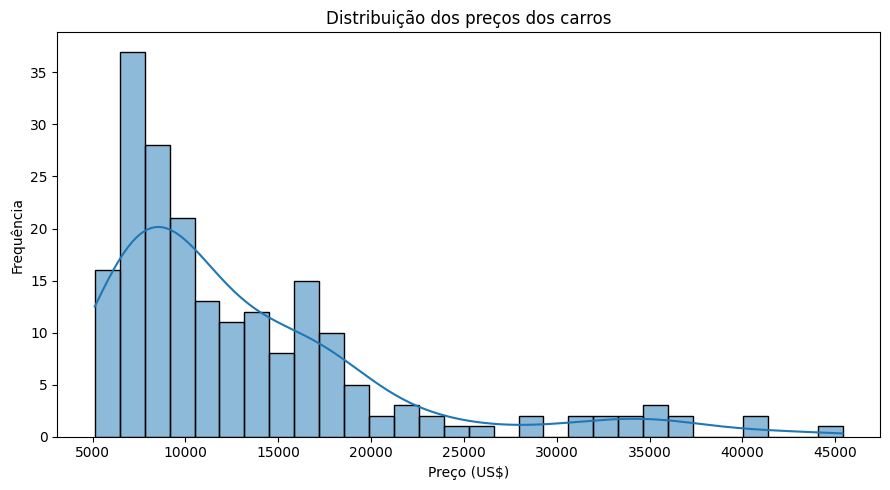

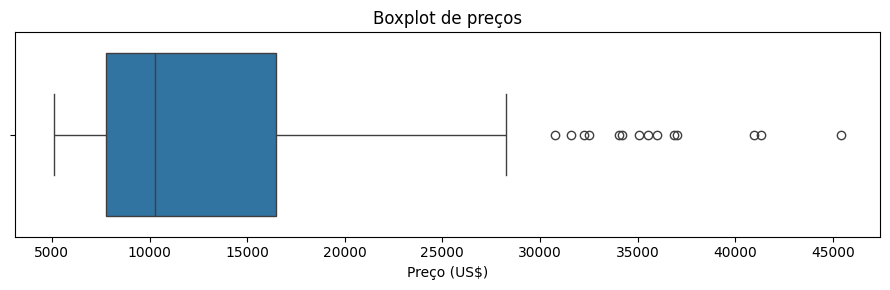

In [15]:
# Passo 02 - Análise da variável-alvo (price)

s_price = pd.to_numeric(df['price'], errors='coerce').dropna()

print(f"N={len(s_price)} | min={s_price.min():.2f} | mediana={s_price.median():.2f} | "
      f"média={s_price.mean():.2f} | p90={s_price.quantile(0.90):.2f} | max={s_price.max():.2f}")

plt.figure(figsize=(9,5))
sns.histplot(s_price, bins=30, kde=True)
plt.title('Distribuição dos preços dos carros')
plt.xlabel('Preço (US$)'); plt.ylabel('Frequência')
plt.tight_layout(); plt.show()

plt.figure(figsize=(9,3))
sns.boxplot(x=s_price)
plt.title('Boxplot de preços'); plt.xlabel('Preço (US$)')
plt.tight_layout(); plt.show()

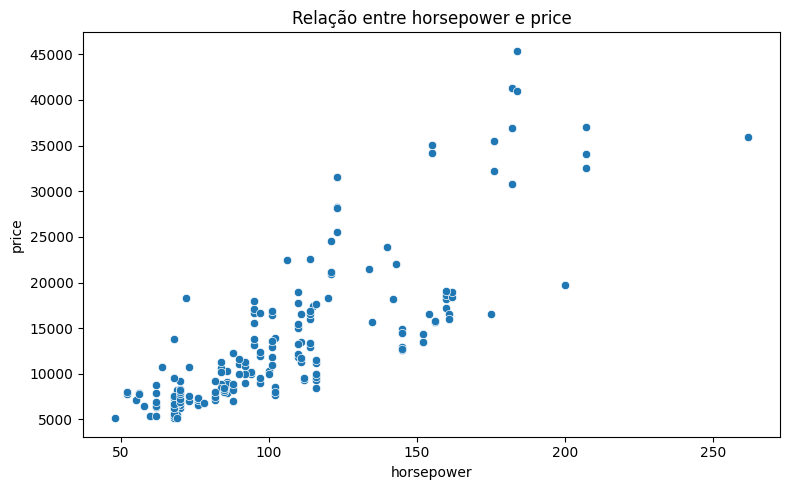

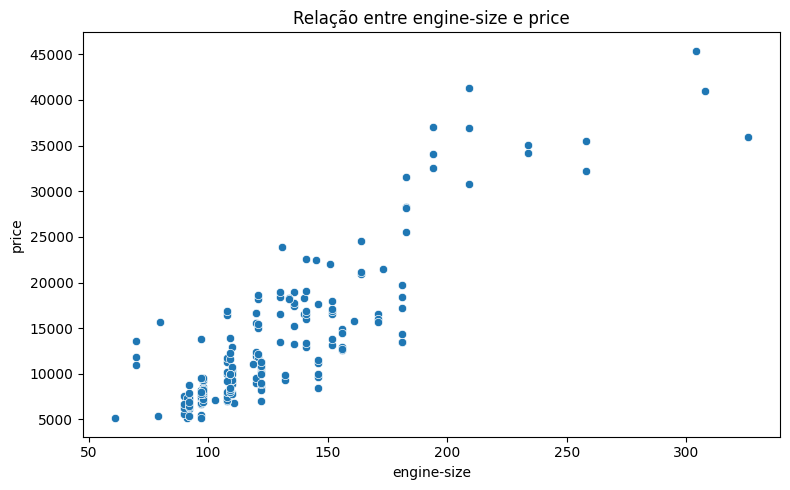

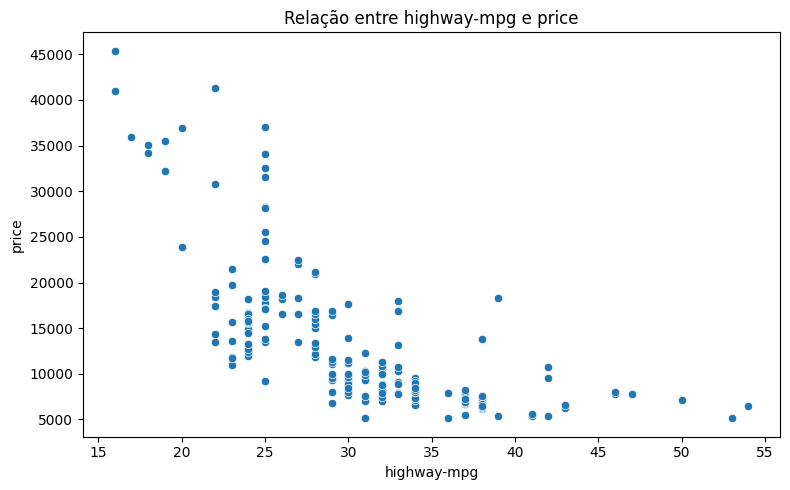

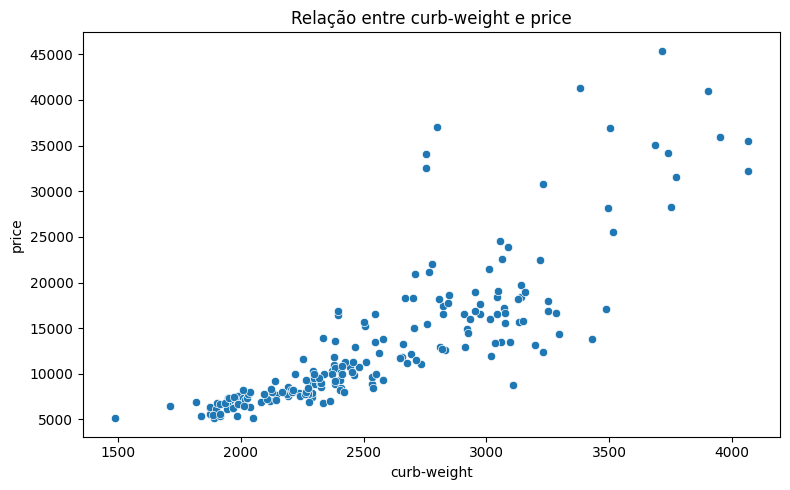

Correlação (Pearson) com price:


,pearson
price,1.000000
engine-size,0.872335
curb-weight,0.834415
horsepower,0.810533
width,0.751265
length,0.690628
wheel-base,0.584642
bore,0.543436
normalized-losses,0.203254
height,0.135486


In [16]:
# Passo 03 -  Relação entre numéricas e price (scatter)

targets = ['horsepower','engine-size','highway-mpg','curb-weight']
for col in targets:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x=col, y='price')
    plt.title(f'Relação entre {col} e price')
    plt.tight_layout(); plt.show()

# Correlação x price (apenas numéricas, dropna pareado)
num = df.select_dtypes(include='number')
corr_price = num.corr(numeric_only=True)['price'].sort_values(ascending=False)
print("Correlação (Pearson) com price:")
display(corr_price.to_frame('pearson'))

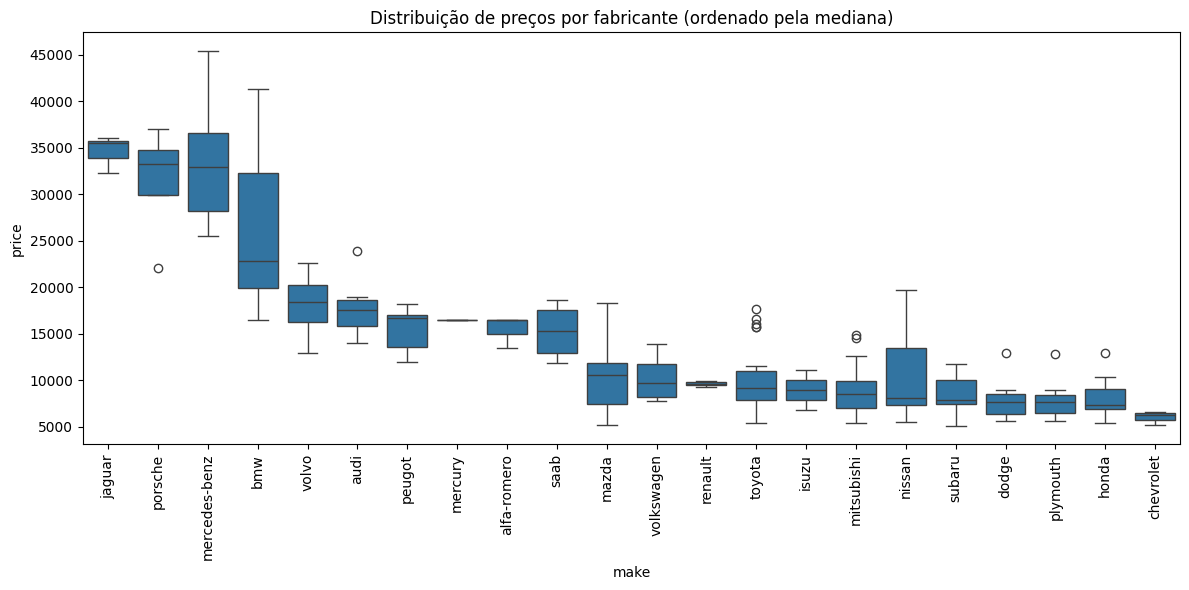

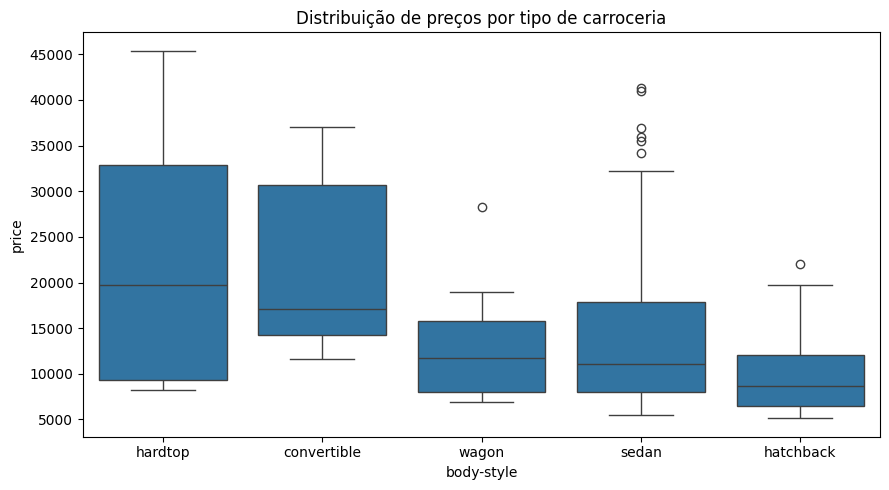

In [17]:
# Passo 4 — Relação entre categóricas e price (boxplot)


# Boxplot por fabricante (ordenado pela mediana do preço)
order_make = df.groupby('make')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='make', y='price', order=order_make)
plt.title('Distribuição de preços por fabricante (ordenado pela mediana)')
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

# Boxplot por body-style
order_body = df.groupby('body-style')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='body-style', y='price', order=order_body)
plt.title('Distribuição de preços por tipo de carroceria')
plt.tight_layout(); plt.show()

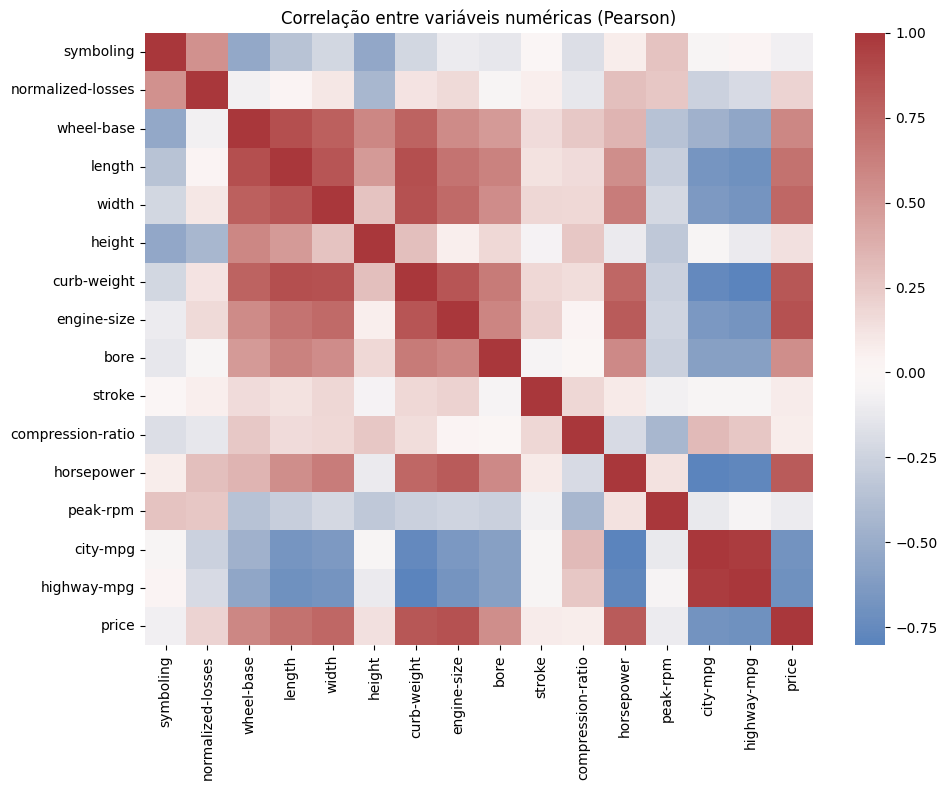

Top correlações absolutas com price:


,abs_pearson
price,1.000000
engine-size,0.872335
curb-weight,0.834415
horsepower,0.810533
width,0.751265
highway-mpg,0.704692
length,0.690628
city-mpg,0.686571
wheel-base,0.584642
bore,0.543436


In [18]:
# Passo 5 — Heatmap de correlação (visão geral numéricas)

num = df.select_dtypes(include='number')
corr = num.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='vlag', center=0)
plt.title('Correlação entre variáveis numéricas (Pearson)')
plt.tight_layout(); plt.show()

# Top correlações (absolutas) com price
top_abs = corr['price'].abs().sort_values(ascending=False).head(10)
print("Top correlações absolutas com price:")
display(top_abs.to_frame('abs_pearson'))